<a href="https://colab.research.google.com/github/gnicula/MSQT/blob/main/AFM_TERS_analysis_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [920]:
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
# from scipy.ndimage import gaussian_filter, map_coordinates
# from scipy.optimize import curve_fit


In [921]:
# Parsers for the two exported text files.
#
# Why this exists:
# - The AFM export is a "grid + metadata" text file. We need scan size + grid size + units, then reconstruct a 2D height image.
# - The TERS export is a "grid + spectrum" text file. We need map dimensions (nx, ny), number of spectral points (nspec),
#   excitation wavelength (lambda0), the wavelength axis, then the intensity cube (nx*ny spectra).
#
# Design goals:
# - Be tolerant to whitespace/encoding oddities in instrument exports.
# - Validate assumptions early (raise errors if file length doesn't match header).

def parse_aist_height_txt(path: str):
    header = {}
    rows = []
    in_data = False

    # The AFM file contains:
    #   - Header lines like "XPoints=50", "XSize=1.0", etc.
    #   - Then a data section that may be marked by "[Data]"
    #   - Data lines contain: x_index  y_index  height_value
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            # Some exports explicitly mark the beginning of the numeric grid
            if s.startswith("[Data]"):
                in_data = True
                continue

            # Header key/value parsing until we hit the data region
            if (not in_data) and ("=" in s):
                k, v = s.split("=", 1)
                header[k.strip()] = v.strip()
                continue

            # Data lines: allow tabs, commas, or spaces
            parts = re.split(r"[\t, ]+", s)

            # Expect first two columns to be integer indices
            if len(parts) >= 3 and re.match(r"^-?\d+$", parts[0]) and re.match(r"^-?\d+$", parts[1]):
                in_data = True
                try:
                    xi = int(parts[0])
                    yi = int(parts[1])
                    zi = float(parts[2])
                    rows.append((xi, yi, zi))
                except ValueError:
                    # If a line looks like data but can't parse, skip it
                    continue

    # Pull required metadata from the header.
    # These numbers define the physical grid and its sampling.
    def get_int(k): return int(float(header[k]))
    def get_float(k): return float(header[k])

    XPoints = get_int("XPoints")  # number of samples in X
    YPoints = get_int("YPoints")  # number of samples in Y
    XSize = get_float("XSize")    # physical scan size in X (in XUnits)
    YSize = get_float("YSize")    # physical scan size in Y (in YUnits)
    XUnits = header.get("XUnits", "um")
    YUnits = header.get("YUnits", "um")
    ZUnits = header.get("ZUnits", "nm")

    if len(rows) == 0:
        raise ValueError("No AFM data rows found (could not locate numeric grid).")

    # Reconstruct the 2D height map from (x_index, y_index, height).
    # We fill a YPoints×XPoints array so that later code can treat it as an image.
    z2d = np.full((YPoints, XPoints), np.nan, dtype=float)
    for xi, yi, zi in rows:
        if 0 <= xi < XPoints and 0 <= yi < YPoints:
            z2d[yi, xi] = zi

    # If the export is complete, there should be no missing points.
    missing = np.isnan(z2d).sum()
    if missing:
        raise ValueError(f"AFM map has {missing} missing points (expected a full {YPoints}×{XPoints} grid).")

    meta = dict(
        XPoints=XPoints, YPoints=YPoints,
        XSize=XSize, YSize=YSize,
        XUnits=XUnits, YUnits=YUnits, ZUnits=ZUnits
    )
    return header, z2d, meta


In [922]:
def parse_aist_specdata_txt(path: str):
    # The TERS file is organized as:
    #   line 1: nx  ny  nspec  lambda0_nm
    #   line 2: wavelength axis values (nspec numbers, in nm)
    #   remaining: intensity values, flattened (nx*ny*nspec numbers)
    #
    # This format is enough to reconstruct a spectra matrix shaped:
    #   (nx*ny pixels) × (nspec spectral channels)

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        first = f.readline().strip().split()
        if len(first) < 4:
            raise ValueError("First line must be: nx ny nspec lambda0_nm")

        nx = int(float(first[0]))
        ny = int(float(first[1]))
        nspec = int(float(first[2]))
        lam0 = float(first[3])  # excitation wavelength (needed to convert λ -> Raman shift)

        # Wavelength axis: must match nspec exactly
        wav = np.array([float(x) for x in f.readline().strip().split()], dtype=float)
        if wav.size != nspec:
            raise ValueError(f"Wavelength axis has {wav.size} values, expected nspec={nspec}")

        # Remaining file is flattened intensity data
        arr = np.array([float(x) for x in f.read().split()], dtype=float)

    # Validate file completeness: nx*ny spectra, each with nspec channels
    expected = nx * ny * nspec
    if arr.size != expected:
        raise ValueError(f"Intensity count {arr.size}, expected {expected} (=nx*ny*nspec).")

    spec = arr.reshape((nx, ny, nspec))
    header = {"nx": nx, "ny": ny, "nspec": nspec, "λ0": lam0}

    return header, wav, spec


In [923]:
def plot_array(arr, title, xlabel="X", ylabel="Y"):
    plt.figure(figsize=(8, 6))
    plt.imshow(arr, cmap='viridis')
    plt.title(title)
    plt.colorbar(label="Normalized Height")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [924]:
def plot_line_over_img(arr, line, title="Detected Line", color="r"):
    plt.figure(figsize=(8, 6))
    plt.imshow(arr, cmap='viridis')
    plt.title(title)
    plt.colorbar(label="Normalized Height")

    if line is not None:
        x1, y1, x2, y2 = line
        plt.plot([x1, x2], [y1, y2], color=color, linewidth=2, label="Longest Line")
        plt.legend()
    else:
        print("No line to plot.")

    plt.show()

In [925]:
def prepare_z2d(z2d, blur_factor):
    # Calculate mean and standard deviation for Z-score normalization
    mean = np.mean(z2d)
    std = np.std(z2d)

    # Normalize (handle division by zero if std is 0)
    if std == 0:
        z_norm = np.zeros_like(z2d)
    else:
        z_norm = (z2d - mean) / std

    # Apply Gaussian blur using OpenCV
    # Using a 5x5 kernel size with default sigma (0 means computed from kernel size)
    z_blurred = cv2.GaussianBlur(z_norm, (blur_factor, blur_factor), 0)

    return z_blurred

In [926]:
def get_edges(z2d_image, canny_low, canny_high, reversed=False):
    # Normalize to 0-255 uint8 for OpenCV (Hough/Canny expect 8-bit)
    img_norm = cv2.normalize(z2d_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if reversed:
      img_norm = cv2.bitwise_not(img_norm)
    plot_array(img_norm, f"Input image for edge detection, reversed={reversed}")
    # Edge detection
    edges = cv2.Canny(img_norm, canny_low, canny_high)
    return edges

def get_binary_image(arr, binary_low, binary_high):
  img_norm = cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
  img_binary = cv2.threshold(img_norm, 127, 255, cv2.THRESH_BINARY)
  return img_binary

def get_longest_line(edges, hough_threshold, min_line_len, max_line_gap):
    # Detect lines using Probabilistic Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=hough_threshold,
                            minLineLength=min_line_len, maxLineGap=max_line_gap)

    if lines is None:
        print("Error: No lines detected.")
        return None

    # Find the longest line
    longest_line = None
    max_len = -1.0

    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if length > max_len:
            max_len = length
            longest_line = (x1, y1, x2, y2)

    return longest_line

In [927]:
def get_peak_features(line, img, max_distance, peak_height, rel_height):
    mask = np.zeros_like(img)
    if line is None:
        return mask

    x1, y1, x2, y2 = line

    # 1. Sample points along the line
    length = int(np.hypot(x2 - x1, y2 - y1))
    if length == 0: return mask

    # Generate coordinates
    t = np.linspace(0, 1, length)
    xs = (x1 + t * (x2 - x1)).astype(int)
    ys = (y1 + t * (y2 - y1)).astype(int)

    # Clip to image bounds
    h, w = img.shape
    valid_coords = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
    xs = xs[valid_coords]
    ys = ys[valid_coords]
    if len(xs) == 0: return mask

    # 2. Analyze profile along the line
    line_profile = img[ys, xs]
    peaks_l, _ = find_peaks(line_profile, height=peak_height)
    widths_l, _, left_l, right_l = peak_widths(line_profile, peaks_l, rel_height=rel_height)

    # Create a mask for valid points on the line (indices in xs/ys)
    valid_indices_l = np.zeros(len(xs), dtype=bool)
    for i in range(len(peaks_l)):
        l_idx = int(np.floor(left_l[i]))
        r_idx = int(np.ceil(right_l[i]))
        # Clamp indices
        l_idx = max(0, l_idx)
        r_idx = min(len(xs), r_idx)
        valid_indices_l[l_idx:r_idx] = True

    # 3. Analyze column profiles for valid line points
    for i in range(len(xs)):
        if not valid_indices_l[i]:
            continue

        x_curr = xs[i]
        y_curr = ys[i]

        col_profile = img[:, x_curr]
        peaks_c, _ = find_peaks(col_profile, height=peak_height)
        widths_c, _, left_c, right_c = peak_widths(col_profile, peaks_c, rel_height=rel_height)

        # Check if y_curr falls within any peak width in the column
        for j in range(len(peaks_c)):
            l_pos = left_c[j]
            r_pos = right_c[j]

            # If the line point is inside the column peak's width
            if l_pos <= y_curr <= r_pos:
                # Mark the full thickness of the object at this column
                y_start = int(np.floor(l_pos))
                y_end = int(np.ceil(r_pos))
                y_start = max(0, y_start)
                y_end = min(h, y_end)

                mask[y_start:y_end, x_curr] = 1
                # We found the peak this point belongs to, move to next point
                break

    return mask

In [928]:
def prepare_ters_data(ters_header, wav_nm, spec, band_lo, band_hi):
  # Raman shift (cm^-1): shift = (1/λ0 - 1/λ) * 1e7  with λ in nm
  lam0 = ters_header["λ0"]
  ny_t = ters_header["ny"]
  nx_t = ters_header["nx"]
  nspec = ters_header["nspec"]
  raman_shift = (1.0/lam0 - 1.0/wav_nm) * 1e7

  band_mask = (raman_shift >= band_lo) & (raman_shift <= band_hi)
  if band_mask.sum() < 3:
      raise ValueError("Band window too narrow or outside Raman shift range. Adjust band_lo/band_hi.")

  ters_band_map = spec[:, :, band_mask].sum(axis=2)

  ters_bans_map_normalized = prepare_z2d(ters_band_map, 3)

  return ters_bans_map_normalized


### Parameters

In [929]:
AFM_PATH  = "/content/XY sample 183 Height(Sen).txt"
TERS_PATH = "/content/XY sample 184 Specdata.txt"

# parameters for preparing
BLUR_FACTOR = 3

# parameters for line detection
CANNY_LOW = 80
CANNY_HIGH = 200
HOUGH_THRESHOLD = 15
MIN_LINE_LEN = 10
MAX_LINE_GAP = 5

# parameters for peak features
MAX_DISTANCE_TO_LINE = 2
PEAK_HEIGHT = 0.0      # Minimum height for peaks (Z-score scale)
PEAK_REL_HEIGHT = 0.5  # Relative height for width calculation (0.5 = FWHM)

# parameters for Raman shift
BAND_LO = 1500
BAND_HI = 1650

In [930]:
def run_colab():
  afm_header, z2d, afm_meta = parse_aist_height_txt(AFM_PATH)
  # print(afm_header)
  ters_header, wav_nm, spec = parse_aist_specdata_txt(TERS_PATH)
  # print(ters_header)
  z2d_prepared = prepare_z2d(z2d, BLUR_FACTOR)
  # plt.imshow(z2d_prepared)
  print("Prepared Z data sample:", z2d_prepared[0][:10])

  afm_edges = get_edges(z2d_prepared, CANNY_LOW, CANNY_HIGH)
  # print(afm_edges[10][:10])
  # plt.imshow(afm_edges)

  line_coords = get_longest_line(afm_edges, HOUGH_THRESHOLD, MIN_LINE_LEN, MAX_LINE_GAP)
  plot_line_over_img(z2d_prepared, line_coords)

  features_mask = get_peak_features(line_coords, z2d_prepared, MAX_DISTANCE_TO_LINE, PEAK_HEIGHT, PEAK_REL_HEIGHT)
  plot_array(features_mask, "Detected Features Mask")

  # now process the TERS file
  ters_raman_shifted_band = prepare_ters_data(ters_header, wav_nm, spec, BAND_LO, BAND_HI)
  plot_array(ters_raman_shifted_band, "Raman Shift Band")
  plot_array(spec[:, :, 418:425].sum(axis=2), "Spec raw")
  # ters_edges = get_edges(ters_raman_shifted_band, CANNY_LOW, CANNY_HIGH)

  # plt.imshow(ters_edges)

Prepared Z data sample: [-0.19260634 -0.20428318 -0.12101259 -0.05244879 -0.13095297 -0.16166006
 -0.18133705 -0.26719463 -0.3934959  -0.42787969]


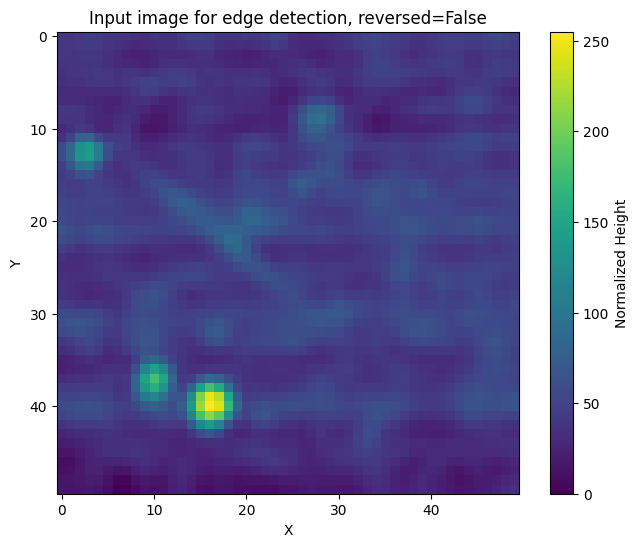

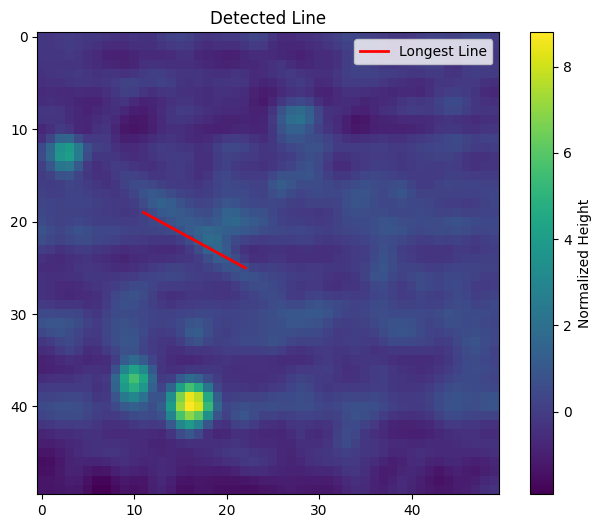

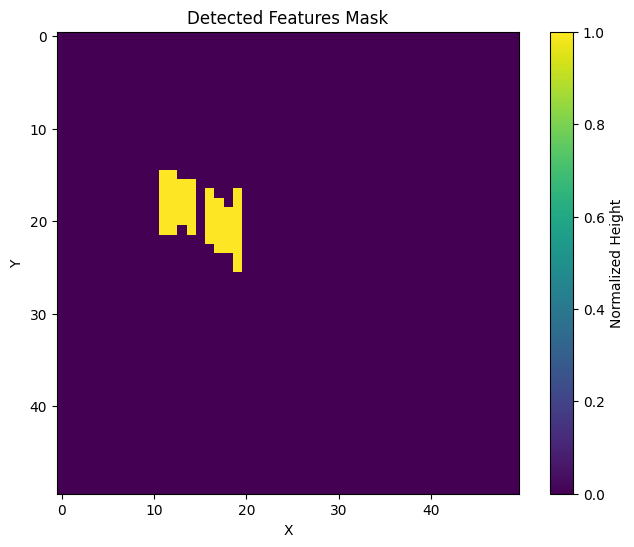

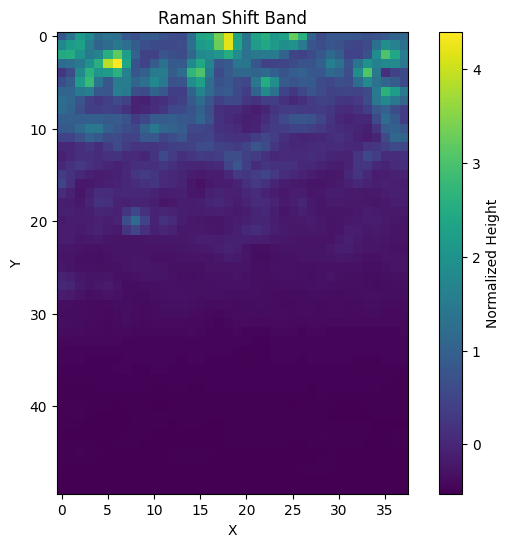

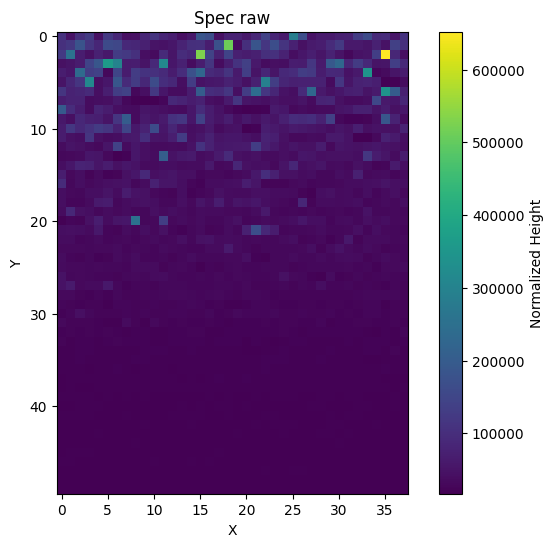

In [931]:
run_colab()